# Peramalan Kadar NO₂ di Daerah Sumenep Madura

## Latar Belakang

Kabupaten Sumenep merupakan salah satu wilayah di Pulau Madura yang memiliki aktivitas transportasi, perdagangan, dan permukiman yang terus berkembang. Seiring dengan meningkatnya aktivitas tersebut, potensi pencemaran udara akibat emisi gas buang kendaraan bermotor dan berbagai aktivitas pembakaran juga semakin meningkat. Salah satu polutan udara yang menjadi perhatian adalah Nitrogen Dioksida (NO₂).

NO₂ merupakan gas pencemar yang dihasilkan terutama dari proses pembakaran bahan bakar fosil, seperti kendaraan bermotor, pembangkit energi, dan aktivitas industri. Keberadaan NO₂ di atmosfer dalam konsentrasi tinggi dapat memberikan dampak negatif terhadap kesehatan manusia, antara lain menyebabkan gangguan sistem pernapasan, iritasi saluran pernapasan, serta memperburuk penyakit asma dan bronkitis. Selain itu, NO₂ juga berkontribusi terhadap pembentukan hujan asam dan penurunan kualitas lingkungan.

Pemantauan konsentrasi NO₂ menjadi penting untuk mengetahui kondisi kualitas udara suatu wilayah serta mengidentifikasi perubahan konsentrasinya dari waktu ke waktu. Dengan memanfaatkan data penginderaan jauh dari satelit Sentinel-5P, konsentrasi NO₂ dapat diamati secara berkala dan mencakup wilayah yang luas. Data tersebut selanjutnya dapat digunakan untuk melakukan analisis dan peramalan kadar NO₂ di Kabupaten Sumenep sehingga dapat memberikan informasi yang bermanfaat dalam mendukung pengelolaan lingkungan dan pengambilan keputusan terkait kualitas udara di masa mendatang.


## 1. Pengumpulan Data

Tahap pertama adalah mengumpulkan data *time series* harian kadar NO₂ di wilayah Kabupaten Sumenep. Data diperoleh dari platform Copernicus Data Space Ecosystem yang menyediakan data pengamatan satelit Sentinel-5P.

Pengambilan data dilakukan menggunakan Python melalui JupyterLab dengan menentukan batas wilayah Kabupaten Sumenep serta rentang waktu pengamatan yang diperlukan. Data yang diperoleh kemudian digunakan untuk proses analisis dan peramalan kadar NO₂.


Sebelum mengambil data NO₂ Kabupaten Sumenep, kita perlu menghubungkan Python dengan layanan Copernicus Data Space Ecosystem. Koneksi ini dilakukan menggunakan library OpenEO.


In [1]:
!pip install openeo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.5/345.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.6 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [3]:
import openeo

In [6]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=FFFL-VCYW 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


Setelah menjalankan proses autentikasi dan login ke akun Copernicus, data satelit dapat diakses dan digunakan untuk proses analisis selanjutnya.

In [10]:
aoi_sumenep = {
    "type": "Polygon",
    "coordinates": [
        [
            [113.07680309239902, -6.877875870487117],
            [112.67449667661083, -6.877875870487117],
            [112.67449667661083, -7.187461929031443],
            [113.07680309239902, -7.187461929031443],
            [113.07680309239902, -6.877875870487117]
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2023-10-01", "2025-10-01"],
    spatial_extent={
        "west": 112.67449667661083,
        "south": -7.187461929031443,
        "east": 113.07680309239902,
        "north": -6.877875870487117
    },
    bands=["NO2"],
)


s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")


s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi_sumenep)

Kode di atas menggunakan koordinat batas wilayah Kabupaten Sumenep sebagai Area of Interest (AOI). Koordinat tersebut dapat diperoleh melalui website **https://geojson.io/** dengan membuat polygon atau kotak pada area yang ingin diteliti.

Setelah koordinat diperoleh, data NO₂ dari satelit Sentinel-5P diambil sesuai rentang waktu yang ditentukan. Selanjutnya dilakukan agregasi harian dan agregasi spasial untuk mendapatkan nilai rata-rata konsentrasi NO₂ yang mewakili seluruh wilayah Kabupaten Sumenep.


In [11]:
job = s5post.execute_batch(title="NO2 in Sumenep", outputfile="NO2Sumenep.nc")

0:00:00 Job 'j-2606030346104e1d9622a01d306d8f55': send 'start'
0:00:32 Job 'j-2606030346104e1d9622a01d306d8f55': queued (progress 0%)
0:00:37 Job 'j-2606030346104e1d9622a01d306d8f55': queued (progress 0%)
0:00:43 Job 'j-2606030346104e1d9622a01d306d8f55': queued (progress 0%)
0:00:51 Job 'j-2606030346104e1d9622a01d306d8f55': queued (progress 0%)
0:01:02 Job 'j-2606030346104e1d9622a01d306d8f55': running (progress N/A)
0:01:14 Job 'j-2606030346104e1d9622a01d306d8f55': running (progress N/A)
0:01:29 Job 'j-2606030346104e1d9622a01d306d8f55': running (progress N/A)
0:01:49 Job 'j-2606030346104e1d9622a01d306d8f55': running (progress N/A)
0:02:13 Job 'j-2606030346104e1d9622a01d306d8f55': running (progress N/A)
0:02:43 Job 'j-2606030346104e1d9622a01d306d8f55': running (progress N/A)
0:03:20 Job 'j-2606030346104e1d9622a01d306d8f55': running (progress N/A)
0:04:07 Job 'j-2606030346104e1d9622a01d306d8f55': running (progress N/A)
0:05:06 Job 'j-2606030346104e1d9622a01d306d8f55': running (progress N

Selanjutnya dilakukan proses pengunduhan data dengan menjalankan batch job. Hasil pengolahan akan disimpan dalam file NetCDF (`.nc`) yang berisi data NO₂ wilayah Kabupaten Sumenep.

Selama proses berlangsung, sistem akan menampilkan status pekerjaan hingga mencapai finished (100%). Setelah proses selesai, file hasil dapat digunakan untuk tahap pemrosesan dan analisis data.


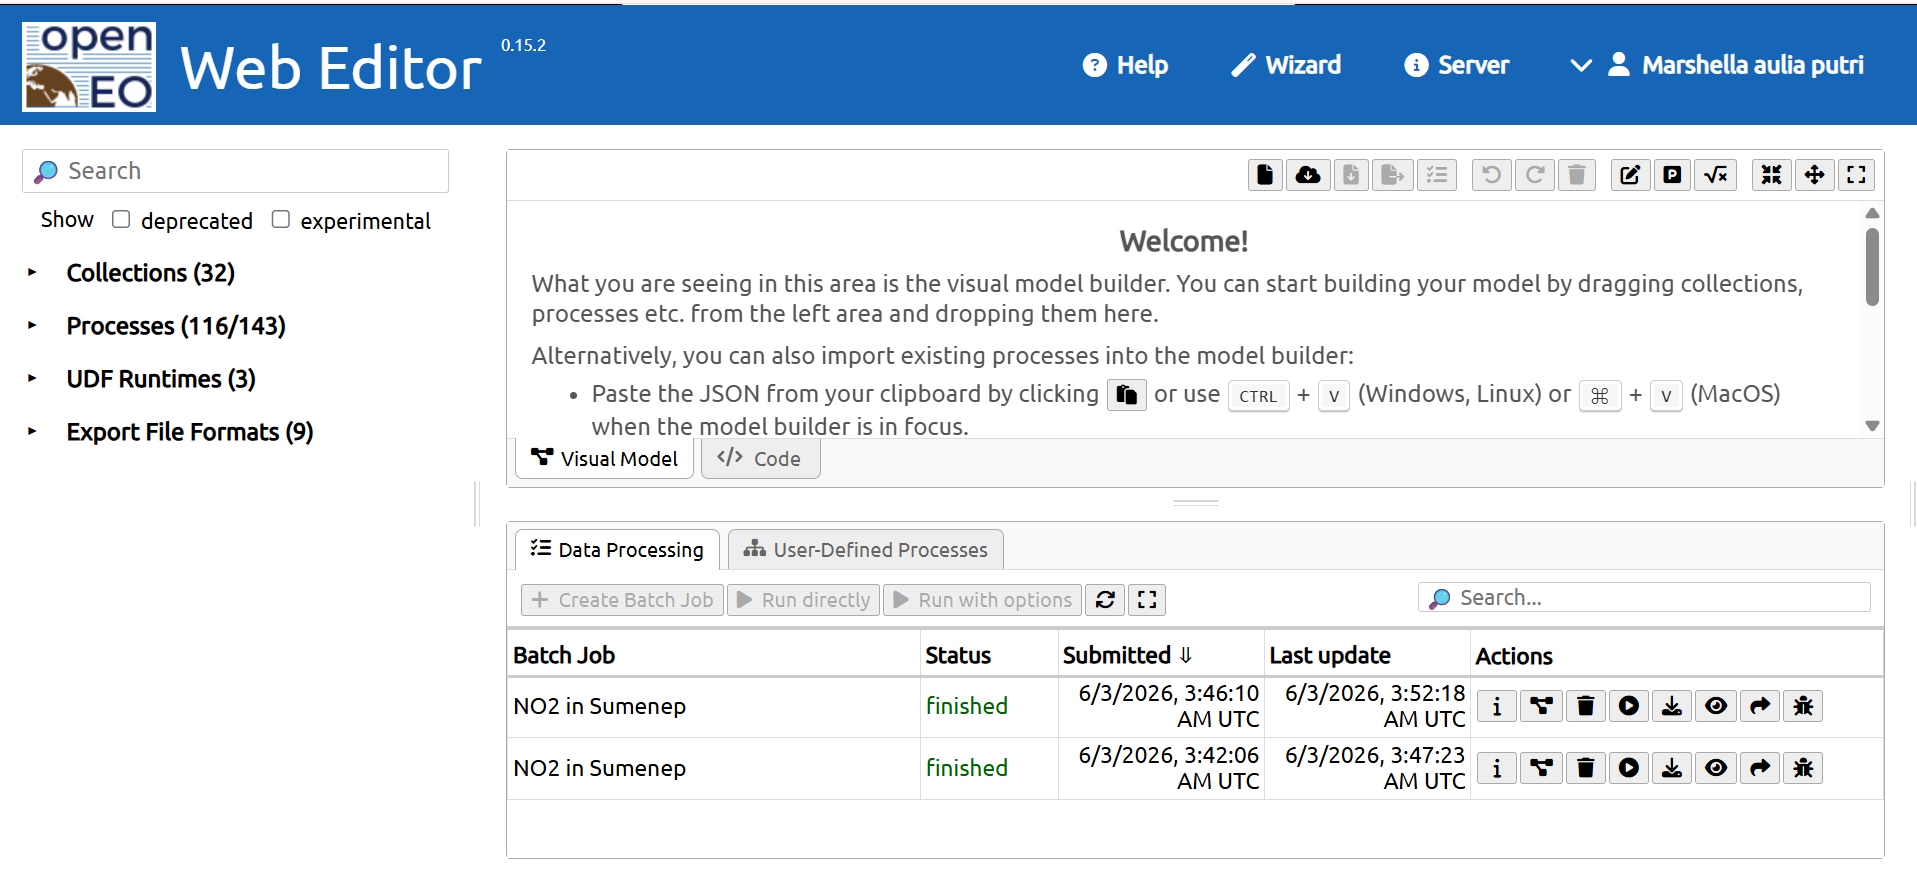

Progres pengambilan data dapat dipantau melalui OpenEO Editor. Halaman tersebut menampilkan status job dan perkembangan proses hingga data berhasil dihasilkan.


In [16]:
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 62.6 MB/s eta 0:00:00


Tahap ini bertujuan untuk memasang library netCDF4 yang diperlukan untuk membaca file hasil pengambilan data NO₂ dalam format `.nc`. Jika proses instalasi berhasil, akan muncul pesan Successfully installed, yang menandakan library siap digunakan untuk analisis data.


## 2. Preproccessing Data

Saving openEO.nc to openEO (6).nc
        date  NO2_mean
0 2023-10-01  0.000028
1 2023-10-02  0.000023
2 2023-10-03  0.000025
3 2023-10-04  0.000016
4 2023-10-05  0.000018
5 2023-10-06  0.000023
6 2023-10-07  0.000017
7 2023-10-08  0.000021
8 2023-10-09  0.000023
9 2023-10-10  0.000029


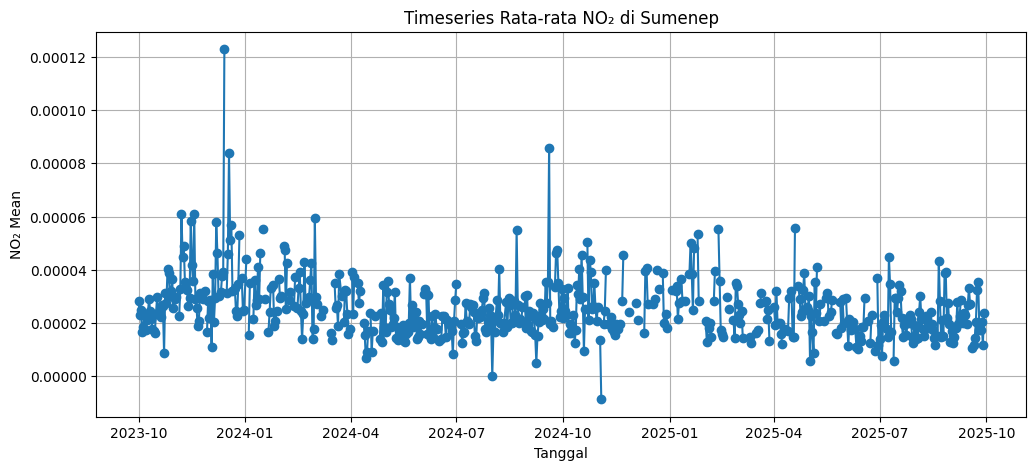

In [52]:
import netCDF4
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Upload file NetCDF
uploaded = files.upload()
file_path = list(uploaded.keys())[0]


ds = netCDF4.Dataset(file_path)


no2 = ds.variables["NO2"][:]  # shape (time, lat, lon)
time = ds.variables["t"][:]

try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time


dates_dt = [pd.to_datetime(d.isoformat()) for d in dates]

no2_mean = np.mean(no2, axis=(1, 2))


df_no2 = pd.DataFrame({
    "date": dates_dt,
    "NO2_mean": no2_mean
})

print(df_no2.head(10))

plt.figure(figsize=(12, 5))
plt.plot(df_no2["date"], df_no2["NO2_mean"], marker='o')
plt.title("Timeseries Rata-rata NO₂ di Sumenep")
plt.xlabel("Tanggal")
plt.ylabel("NO₂ Mean")
plt.grid(True)
plt.show()

Kode ini digunakan untuk mengolah data NO₂ hasil unduhan, menghitung nilai rata-rata harian, dan menampilkan grafik perubahan konsentrasi NO₂ di Kabupaten Sumenep selama periode pengamatan.


In [24]:
print("Contoh data pertama:")
for i in range(0, 10):
    print(no2[i])

Contoh data pertama:
[[2.8623848265851848e-05 4.4227883336134255e-05 2.893842975026928e-05
  2.1328460206859745e-05 8.209470252040774e-06 2.586452137620654e-05
  1.563638579682447e-05 9.385486009705346e-06]
 [3.770179318962619e-05 4.4227883336134255e-05 3.226231274311431e-05
  2.7030169803765602e-05 8.209470252040774e-06 3.680306326714344e-05
  3.0760795198148116e-05 9.385486009705346e-06]
 [2.7158148441230878e-05 3.1096213206183165e-05 3.226231274311431e-05
  2.0787138055311516e-05 2.2647607693215832e-05 3.680306326714344e-05
  2.544464950915426e-05 2.3946160581544973e-05]
 [2.7158148441230878e-05 3.772687341552228e-05 4.294700556783937e-05
  2.0787138055311516e-05 4.394538700580597e-05 3.6170044040773064e-05
  2.544464950915426e-05 3.904499681084417e-05]
 [2.9651806471520104e-05 3.772687341552228e-05 -- 5.6563803809694946e-05
  4.394538700580597e-05 -- 6.348737952066585e-05 3.904499681084417e-05]
 [3.303916673758067e-05 4.1052295273402706e-05 -- -- -- -- -- --]
 [3.303916673758067e-0

Kode di atas digunakan untuk menampilkan beberapa data NO₂ pertama yang tersimpan pada file NetCDF. Tujuannya adalah untuk memeriksa apakah data berhasil terbaca dan melihat bentuk serta nilai awal dari data NO₂ yang akan dianalisis.


### a. Mengatasi Missing Value menggunakan metode Interpolasi Linear

In [25]:
import numpy as np
import pandas as pd

# Interpolasi Linear
no2_filled = np.zeros_like(no2)
# Untuk jaga-jaga jika terdapat '--' tidak berubah menjadi 0
no2_filled = no2_filled.filled(0)

# loop tiap grid (y,x)
for i in range(no2.shape[1]):     # 9 baris
    for j in range(no2.shape[2]): # 8 kolom
        series = pd.Series(no2[:, i, j])
        no2_filled[:, i, j] = series.interpolate(method='linear', limit_direction='both').to_numpy()


Tahap ini dilakukan untuk mengisi data NO₂ yang kosong atau hilang menggunakan metode Interpolasi Linear. Nilai yang hilang diperkirakan berdasarkan pola data sebelum dan sesudahnya agar data menjadi lebih lengkap sebelum digunakan pada proses analisis.


### b. Rata-rata kan Data dan ubah Datetime

In [26]:
new_dates = []
new_no2 = []
for i in range(len(dates)):
    # ubah format datetime
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    new_no2.append(np.mean(no2_filled[i]))

data NO₂ yang sudah diperbaiki kemudian dirata-ratakan untuk setiap tanggal pengamatan. Tanggal juga diubah ke format datetime agar lebih mudah dibaca dan digunakan dalam analisis deret waktu.

### c. Simpan data dalam bentuk CSV

Setelah itu, data disimpan ke dalam format CSV dengan nama file NO2_Sumenep_timeseries.csv. Hasil yang ditampilkan berupa tabel berisi kolom tanggal dan nilai rata-rata NO₂ harian di Kabupaten Sumenep. Data CSV ini nantinya digunakan untuk tahap visualisasi dan peramalan.

In [44]:
# 8️⃣ Simpan ke CSV dan download otomatis
csv_file = "NO2_Sumenep_timeseries.csv"
df.to_csv(csv_file, index=False)
files.download(csv_file)

# 9️⃣ Tampilkan 10 data pertama
print(df.head(10))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

            NO2_mean       NO2
date                          
2023-10-01  0.000026  0.000026
2023-10-02  0.000024  0.000024
2023-10-03  0.000024  0.000024
2023-10-04  0.000022  0.000022
2023-10-05  0.000022  0.000022
2023-10-06  0.000023  0.000023
2023-10-07  0.000022  0.000022
2023-10-08  0.000022  0.000022
2023-10-09  0.000023  0.000023
2023-10-10  0.000028  0.000028


### d. Pengecekan Missing Value data harian pada CSV

 pengecekan kelengkapan data harian  dilakukan dengan membandingkan tanggal yang tersedia pada dataset terhadap rentang tanggal pengamatan. Hasil pengecekan digunakan untuk memastikan data telah lengkap sebelum dilakukan analisis dan peramalan.


In [41]:
import pandas as pd
from google.colab import files

# 1️⃣ Upload CSV via Choose File
uploaded = files.upload()
csv_file = list(uploaded.keys())[0]

# 2️⃣ Baca CSV
df = pd.read_csv(csv_file)

# Pastikan kolom 'date' bertipe datetime
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap sesuai periode data
start_date = df['date'].min()  # tanggal pertama di CSV
end_date = df['date'].max()    # tanggal terakhir di CSV
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Saving NO2_Sumenep_timeseries.csv to NO2_Sumenep_timeseries (5).csv
Jumlah hari missing: 6
Daftar tanggal missing:
DatetimeIndex(['2023-11-11', '2024-01-01', '2024-03-23', '2024-08-12',
               '2025-01-30', '2025-01-31'],
              dtype='datetime64[ns]', freq=None)


Data yang masih memiliki tanggal kosong diperbaiki dengan cara melengkapi seluruh rentang tanggal pengamatan terlebih dahulu. Setelah itu, nilai NO₂ yang kosong diisi menggunakan **Interpolasi Linear** berdasarkan urutan waktu.

Hasil akhirnya disimpan menjadi file CSV baru, sehingga data NO₂ Kabupaten Sumenep sudah lengkap dan siap digunakan untuk analisis berikutnya.


In [42]:
import pandas as pd
from google.colab import files

# 1️⃣ Upload CSV via Choose File
uploaded = files.upload()
csv_file = list(uploaded.keys())[0]

# 2️⃣ Baca CSV
df = pd.read_csv(csv_file)

# Pastikan kolom 'date' bertipe datetime dan urut
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# 3️⃣ Buat rentang tanggal lengkap
start_date = df['date'].min()
end_date = df['date'].max()
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# 4️⃣ Reindex supaya tanggal yang hilang muncul sebagai NaN
df = df.set_index('date').reindex(full_range)
df.index.name = 'date'

# 5️⃣ Interpolasi linear berdasarkan waktu
df['NO2'] = df['NO2_mean'].interpolate(method='time')

# 6️⃣ (Opsional) Isi NaN awal/akhir jika masih ada
df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')

# 7️⃣ Simpan kembali ke CSV dan download
df.to_csv("NO2_Sumenep_timeseries_interpolated.csv")
files.download("NO2_Sumenep_timeseries_interpolated.csv")

# 8️⃣ Tampilkan 10 data pertama
print(df.head(10))

Saving NO2_Sumenep_timeseries.csv to NO2_Sumenep_timeseries (6).csv


/tmp/ipykernel_2055/3809830956.py:28: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

            NO2_mean       NO2
date                          
2023-10-01  0.000026  0.000026
2023-10-02  0.000024  0.000024
2023-10-03  0.000024  0.000024
2023-10-04  0.000022  0.000022
2023-10-05  0.000022  0.000022
2023-10-06  0.000023  0.000023
2023-10-07  0.000022  0.000022
2023-10-08  0.000022  0.000022
2023-10-09  0.000023  0.000023
2023-10-10  0.000028  0.000028


Saving NO2_Sumenep_timeseries.csv to NO2_Sumenep_timeseries (8).csv
Jumlah hari missing: 0


/tmp/ipykernel_2055/2806028538.py:27: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')


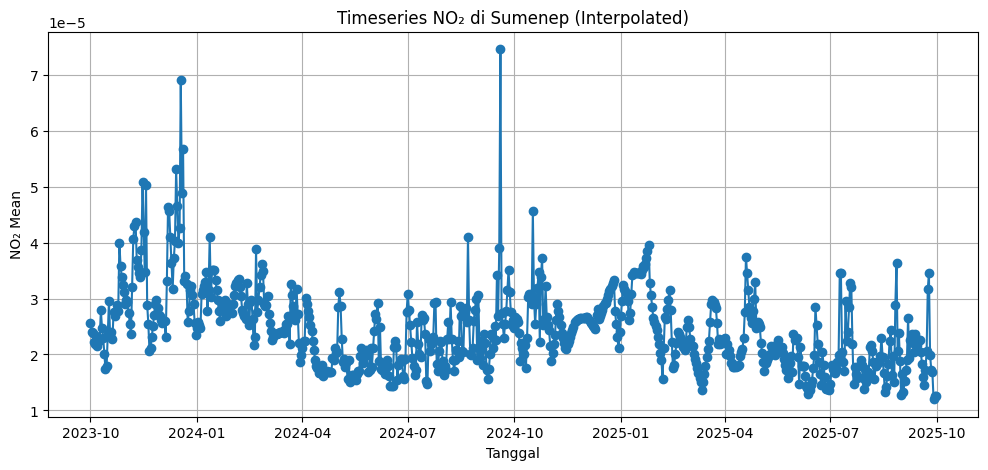

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

            NO2_mean       NO2
date                          
2023-10-01  0.000026  0.000026
2023-10-02  0.000024  0.000024
2023-10-03  0.000024  0.000024
2023-10-04  0.000022  0.000022
2023-10-05  0.000022  0.000022
2023-10-06  0.000023  0.000023
2023-10-07  0.000022  0.000022
2023-10-08  0.000022  0.000022
2023-10-09  0.000023  0.000023
2023-10-10  0.000028  0.000028


In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# 1️⃣ Upload CSV yang sudah dihasilkan sebelumnya
uploaded = files.upload()
csv_file = list(uploaded.keys())[0]

# 2️⃣ Baca CSV
df = pd.read_csv(csv_file)

# 3️⃣ Pastikan kolom 'date' bertipe datetime dan urut
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# 4️⃣ Buat rentang tanggal lengkap
full_range = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='D')

# 5️⃣ Reindex supaya tanggal yang hilang muncul sebagai NaN
df = df.set_index('date').reindex(full_range)
df.index.name = 'date'

# 6️⃣ Interpolasi linear berdasarkan waktu
df['NO2'] = df['NO2_mean'].interpolate(method='time')

# 7️⃣ Isi NaN awal/akhir jika masih ada
df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')

# 8️⃣ Tampilkan jumlah dan tanggal missing (seharusnya 0)
missing_after = df[df['NO2'].isna()]
print(f"Jumlah hari missing: {len(missing_after)}")
if len(missing_after) > 0:
    print("Tanggal missing:")
    print(missing_after.index)

# 9️⃣ Plot timeseries NO2
plt.figure(figsize=(12,5))
plt.plot(df.index, df['NO2'], marker='o')
plt.title("Timeseries NO₂ di Sumenep (Interpolated)")
plt.xlabel("Tanggal")
plt.ylabel("NO₂ Mean")
plt.grid(True)
plt.show()

# 🔟 Simpan CSV final
csv_out = "NO2_Sumenep_timeseries_final.csv"
df.to_csv(csv_out)
files.download(csv_out)

# 1️⃣1️⃣ Tampilkan 10 baris pertama (output seperti screenshotmu)
print(df.head(10))

Data hasil interpolasi divisualisasikan dalam bentuk grafik *time series* untuk melihat perubahan kadar NO₂ dari waktu ke waktu. Hasil pengecekan menunjukkan bahwa tidak terdapat lagi *missing value*, sehingga data siap digunakan untuk analisis dan peramalan.


### e. Deteksi Outlier IQR

Saving NO2_Sumenep_timeseries.csv to NO2_Sumenep_timeseries (10).csv
Kolom CSV: Index(['date', 'NO2_mean'], dtype='object')
Jumlah Outlier (IQR): 14
         date  NO2_mean
38 2023-11-08  0.000043
39 2023-11-09  0.000044
44 2023-11-15  0.000051
47 2023-11-18  0.000050
66 2023-12-07  0.000046


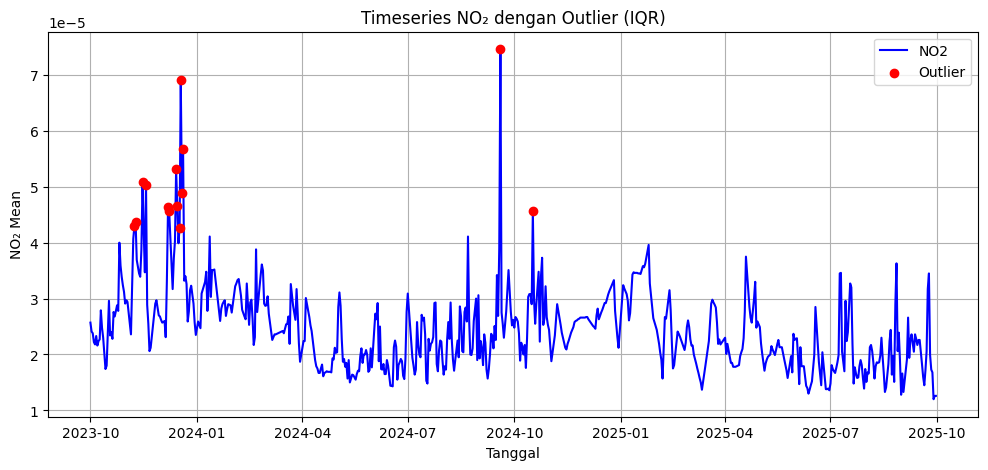

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload CSV
uploaded = files.upload()
csv_file = list(uploaded.keys())[0]

df = pd.read_csv(csv_file)

# Lihat nama kolom untuk memastikan
print("Kolom CSV:", df.columns)

# Ganti 'NO2_mean' dengan nama kolom yang benar di CSV
df['date'] = pd.to_datetime(df['date'])

# Hitung IQR
Q1 = df['NO2_mean'].quantile(0.25)
Q3 = df['NO2_mean'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['NO2_mean'] < lower_bound) | (df['NO2_mean'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2_mean']].head())

# Plot timeseries dengan outlier
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['NO2_mean'], label='NO2', color='blue')
plt.scatter(outliers_iqr['date'], outliers_iqr['NO2_mean'], color='red', label='Outlier', zorder=5)
plt.title("Timeseries NO₂ dengan Outlier (IQR)")
plt.xlabel("Tanggal")
plt.ylabel("NO₂ Mean")
plt.grid(True)
plt.legend()
plt.show()

Data NO₂ kemudian diperiksa untuk mendeteksi adanya outlier menggunakan metode Interquartile Range (IQR). Data yang berada di luar batas normal akan ditandai sebagai outlier dan ditampilkan pada grafik.

Hasilnya menunjukkan beberapa nilai NO₂ yang menyimpang dari pola umum data. Titik-titik tersebut ditandai dengan warna merah sehingga lebih mudah diidentifikasi dan dianalisis.





Untuk mengetahui adanya nilai yang menyimpang, dilakukan deteksi outlier menggunakan metode **IQR**. Hasilnya divisualisasikan dalam bentuk grafik dengan penanda khusus pada data yang teridentifikasi sebagai outlier.


Untuk men-visualisasi outlier:


Saving NO2_Sumenep_timeseries.csv to NO2_Sumenep_timeseries (11).csv
Jumlah hari missing sebelum interpolasi: 6
Tanggal missing sebelum interpolasi:
DatetimeIndex(['2023-11-11', '2024-01-01', '2024-03-23', '2024-08-12',
               '2025-01-30', '2025-01-31'],
              dtype='datetime64[ns]', freq=None)

Jumlah hari missing setelah interpolasi: 0

Jumlah Outlier (IQR): 14
            NO2_mean
date                
2023-11-08  0.000043
2023-11-09  0.000044
2023-11-15  0.000051
2023-11-18  0.000050
2023-12-07  0.000046


/tmp/ipykernel_2055/1354623909.py:31: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['NO2_mean'] = df['NO2_mean'].fillna(method='bfill').fillna(method='ffill')


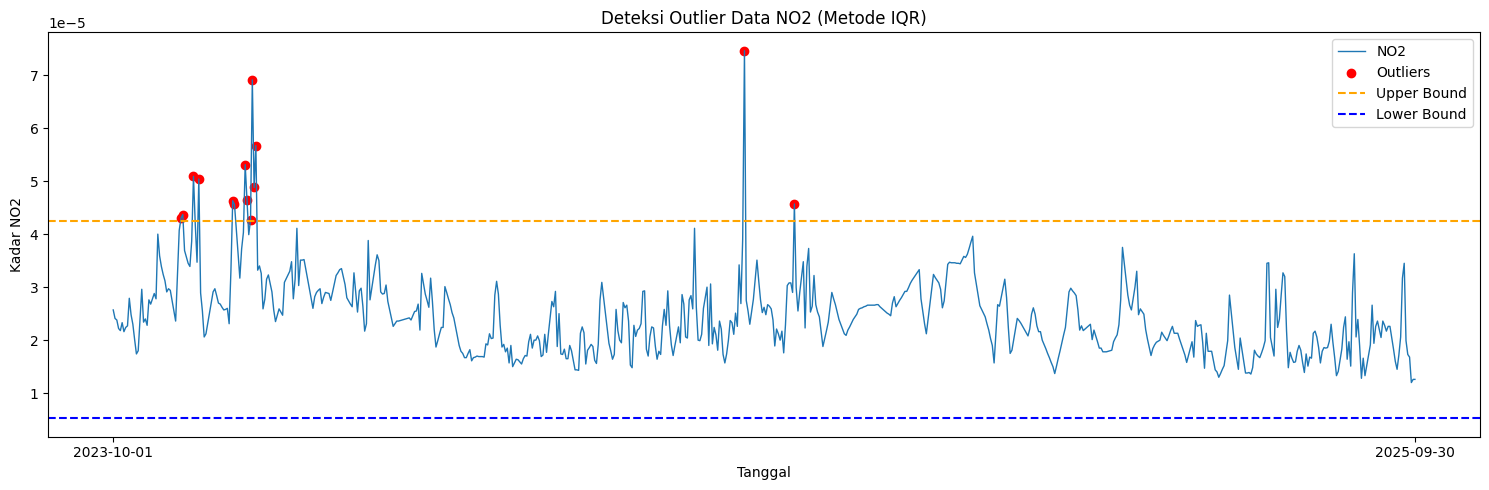

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

            NO2_mean
date                
2023-10-01  0.000026
2023-10-02  0.000024
2023-10-03  0.000024
2023-10-04  0.000022
2023-10-05  0.000022
2023-10-06  0.000023
2023-10-07  0.000022
2023-10-08  0.000022
2023-10-09  0.000023
2023-10-10  0.000028


In [49]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# 1️⃣ Upload CSV hasil interpolasi
uploaded = files.upload()
csv_file = list(uploaded.keys())[0]

# 2️⃣ Baca CSV
df = pd.read_csv(csv_file)

# Pastikan kolom 'date' bertipe datetime dan diurutkan
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# 3️⃣ Cek missing value sebelum interpolasi
full_range = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='D')
missing_before = full_range.difference(df['date'])
print(f"Jumlah hari missing sebelum interpolasi: {len(missing_before)}")
print("Tanggal missing sebelum interpolasi:")
print(missing_before)

# 4️⃣ Reindex supaya tanggal yang hilang muncul sebagai NaN
df = df.set_index('date').reindex(full_range)
df.index.name = 'date'

# 5️⃣ Interpolasi linear
df['NO2_mean'] = df['NO2_mean'].interpolate(method='time')

# 6️⃣ Isi NaN awal/akhir jika ada
df['NO2_mean'] = df['NO2_mean'].fillna(method='bfill').fillna(method='ffill')

# 7️⃣ Cek missing value setelah interpolasi
missing_after = df[df['NO2_mean'].isna()]
print(f"\nJumlah hari missing setelah interpolasi: {len(missing_after)}")
if len(missing_after) > 0:
    print("Tanggal missing:")
    print(missing_after.index)

# 8️⃣ Deteksi outlier IQR
Q1 = df['NO2_mean'].quantile(0.25)
Q3 = df['NO2_mean'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['NO2_mean'] < lower_bound) | (df['NO2_mean'] > upper_bound)]

print(f"\nJumlah Outlier (IQR): {len(outliers_iqr)}")
print(outliers_iqr[['NO2_mean']].head())

# 9️⃣ Visualisasi timeseries NO2 + outlier + batas IQR
plt.figure(figsize=(15,5))
plt.plot(df.index, df['NO2_mean'], label="NO2", linewidth=1)
plt.scatter(outliers_iqr.index, outliers_iqr['NO2_mean'], color='red', marker='o', label="Outliers")
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound")
plt.axhline(lower_bound, color='blue', linestyle='dashed', label="Lower Bound")
plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df.index[0], df.index[-1]],
    labels=[df.index[0].strftime('%Y-%m-%d'), df.index[-1].strftime('%Y-%m-%d')]
)
plt.show()

# 🔟 Simpan CSV final dan download
csv_out = "NO2_Sumenep_timeseries_final.csv"
df.to_csv(csv_out)
files.download(csv_out)

# 1️⃣1️⃣ Tampilkan 10 data pertama
print(df.head(10))

Nilai yang teridentifikasi sebagai outlier kemudian diganti menjadi nilai kosong (*NaN*) dan diperbaiki menggunakan metode Interpolasi Linear. Proses ini dilakukan agar data yang menyimpang tidak memengaruhi hasil analisis.

Berdasarkan hasil pengolahan, terdapat 14 outlier yang berhasil diperbaiki dan tidak ditemukan lagi nilai kosong setelah proses interpolasi selesai.


In [53]:
# Tandai outlier menjadi NaN
df['NO2_cleaned'] = df['NO2_mean'].mask((df['NO2_mean'] < lower_bound) | (df['NO2_mean'] > upper_bound))

print("Jumlah nilai yang dinyatakan sebagai outlier:", df['NO2_cleaned'].isna().sum())

# Interpolasi linear untuk mengisi kembali nilai outlier
df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear')

# Jika masih ada NaN di ujung data, isi dengan forward/backward fill
df['NO2_filled'] = df['NO2_filled'].bfill().ffill()

print("Jumlah missing setelah interpolasi:", df['NO2_filled'].isna().sum())

# Simpan CSV final
df.to_csv("NO2_Sumenep_timeseries_cleaned_final.csv")

Jumlah nilai yang dinyatakan sebagai outlier: 14
Jumlah missing setelah interpolasi: 0


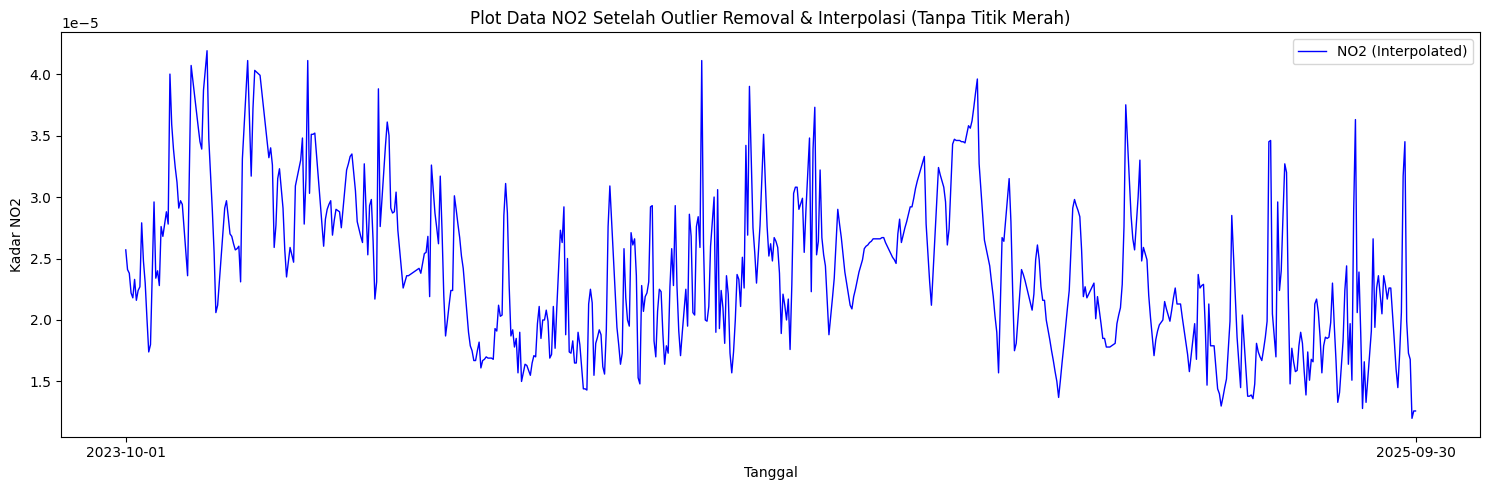

In [55]:
plt.figure(figsize=(15,5))

# Plot data hasil interpolasi (tanpa titik merah)
plt.plot(df.index, df['NO2_filled'], label="NO2 (Interpolated)", linewidth=1, color='blue')

plt.title("Plot Data NO2 Setelah Outlier Removal & Interpolasi (Tanpa Titik Merah)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()

# Tampilkan hanya tanggal awal dan akhir di sumbu X
plt.xticks(
    ticks=[df.index[0], df.index[-1]],
    labels=[df.index[0].strftime('%Y-%m-%d'),
            df.index[-1].strftime('%Y-%m-%d')]
)
plt.show()

Setelah proses perbaikan outlier selesai, data divisualisasikan kembali untuk melihat pola yang telah diperbaiki. Grafik menunjukkan bahwa nilai-nilai yang menyimpang telah dihilangkan dan digantikan dengan nilai hasil interpolasi sehingga pola data menjadi lebih stabil dan siap digunakan pada tahap peramalan.


## 3. Modeling menggunakan KNN Regression

### a. Uji Korelasi Data

Dilakukan uji korelasi untuk mengetahui hubungan antara nilai saat ini dengan nilai pada periode sebelumnya (lag). Pengujian ini bertujuan untuk menentukan seberapa besar pengaruh data historis terhadap data pada waktu berikutnya.

Hasil uji menunjukkan bahwa beberapa nilai lag memiliki tingkat korelasi yang cukup baik, sehingga dapat digunakan sebagai variabel masukan pada proses pemodelan dan peramalan.

In [57]:
import pandas as pd

def create_supervised(data, n_lag=30):
    df_supervised = pd.DataFrame()
    for i in range(n_lag, 0, -1):
        df_supervised[f'NO2(t-{i})'] = data.shift(i)
    df_supervised['NO2(t)'] = data
    df_supervised.dropna(inplace=True)
    return df_supervised

# Baca CSV final yang sudah bersih dan diisi interpolasi
df = pd.read_csv("NO2_Sumenep_timeseries_cleaned_final.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Gunakan kolom NO2_filled untuk supervised learning
supervised_df30 = create_supervised(df['NO2_filled'], n_lag=30)

# Ambil semua lag dan hitung korelasi dengan target
lag_cols = supervised_df30.drop(columns='NO2(t)').columns
correlations = supervised_df30[lag_cols].corrwith(supervised_df30['NO2(t)'])

# Tampilkan korelasi
print(correlations)

NO2(t-30)    0.448247
NO2(t-29)    0.462421
NO2(t-28)    0.465316
NO2(t-27)    0.444677
NO2(t-26)    0.413184
NO2(t-25)    0.395973
NO2(t-24)    0.373945
NO2(t-23)    0.373170
NO2(t-22)    0.380927
NO2(t-21)    0.382023
NO2(t-20)    0.375408
NO2(t-19)    0.356624
NO2(t-18)    0.350816
NO2(t-17)    0.335333
NO2(t-16)    0.342139
NO2(t-15)    0.341479
NO2(t-14)    0.347016
NO2(t-13)    0.347370
NO2(t-12)    0.357292
NO2(t-11)    0.383585
NO2(t-10)    0.418033
NO2(t-9)     0.446688
NO2(t-8)     0.466728
NO2(t-7)     0.473300
NO2(t-6)     0.481856
NO2(t-5)     0.511092
NO2(t-4)     0.548470
NO2(t-3)     0.619079
NO2(t-2)     0.709265
NO2(t-1)     0.834239
dtype: float64


### b. Normalisasi Data

Pada tahap ini dilakukan normalisasi data menggunakan metode Min-Max Scaling. Tujuannya adalah mengubah rentang nilai data menjadi skala 0 hingga 1 sehingga perbedaan nilai yang terlalu besar dapat diminimalkan dan proses pemodelan menjadi lebih optimal.


In [58]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("NO2_Sumenep_timeseries_cleaned_final.csv")
df['date'] = pd.to_datetime(df['date'])

scaler = MinMaxScaler()
df['NO2_scaled'] = scaler.fit_transform(df[['NO2_filled']])

print(df.head())

        date  NO2_mean  NO2_cleaned  NO2_filled  NO2_scaled
0 2023-10-01  0.000026     0.000026    0.000026    0.458194
1 2023-10-02  0.000024     0.000024    0.000024    0.404682
2 2023-10-03  0.000024     0.000024    0.000024    0.394649
3 2023-10-04  0.000022     0.000022    0.000022    0.341137
4 2023-10-05  0.000022     0.000022    0.000022    0.327759


### c. Mengubah Data


Data yang telah dinormalisasi kemudian diubah ke dalam bentuk supervised learning dengan menambahkan beberapa data periode sebelumnya (lag) sebagai variabel masukan. Proses ini bertujuan agar data dapat digunakan sebagai input pada model peramalan.


In [59]:
supervised_df = create_supervised(df['NO2_scaled'], n_lag=4)

print(supervised_df)
print(supervised_df.shape)

     NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
4    0.458194  0.404682  0.394649  0.341137  0.327759
5    0.404682  0.394649  0.341137  0.327759  0.377926
6    0.394649  0.341137  0.327759  0.377926  0.321070
7    0.341137  0.327759  0.377926  0.321070  0.347826
8    0.327759  0.377926  0.321070  0.347826  0.357860
..        ...       ...       ...       ...       ...
726  0.287625  0.658863  0.752508  0.264214  0.177258
727  0.658863  0.752508  0.264214  0.177258  0.160535
728  0.752508  0.264214  0.177258  0.160535  0.000000
729  0.264214  0.177258  0.160535  0.000000  0.020067
730  0.177258  0.160535  0.000000  0.020067  0.020067

[727 rows x 5 columns]
(727, 5)


Data dibuat menjadi bentuk 10 hari sebelumnya dengan parameter `n_lag=10`. Artinya, nilai dari 10 hari terakhir digunakan sebagai variabel masukan untuk memprediksi nilai pada hari saat ini. Hasilnya berupa tabel supervised yang siap digunakan untuk proses pemodelan.


In [60]:
supervised_df10 = create_supervised(df['NO2_scaled'], n_lag=10)

print(supervised_df10)
print(supervised_df10.shape)

     NO2(t-10)  NO2(t-9)  NO2(t-8)  NO2(t-7)  NO2(t-6)  NO2(t-5)  NO2(t-4)  \
10    0.458194  0.404682  0.394649  0.341137  0.327759  0.377926  0.321070   
11    0.404682  0.394649  0.341137  0.327759  0.377926  0.321070  0.347826   
12    0.394649  0.341137  0.327759  0.377926  0.321070  0.347826  0.357860   
13    0.341137  0.327759  0.377926  0.321070  0.347826  0.357860  0.531773   
14    0.327759  0.377926  0.321070  0.347826  0.357860  0.531773  0.428094   
..         ...       ...       ...       ...       ...       ...       ...   
726   0.354515  0.284281  0.210702  0.133779  0.083612  0.173913  0.287625   
727   0.284281  0.210702  0.133779  0.083612  0.173913  0.287625  0.658863   
728   0.210702  0.133779  0.083612  0.173913  0.287625  0.658863  0.752508   
729   0.133779  0.083612  0.173913  0.287625  0.658863  0.752508  0.264214   
730   0.083612  0.173913  0.287625  0.658863  0.752508  0.264214  0.177258   

     NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)  
10   0.347826  0.

### d. Modeling dan Evaluation

In [61]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

def train_knn(df_supervised, model_name=""):
    X = df_supervised.drop(columns=['NO2(t)']).values
    y = df_supervised['NO2(t)'].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = MAPE(y_test, y_pred)
    print(f"\n=== {model_name} ===")
    print(f"Train Size: {len(X_train)} — Test Size: {len(X_test)}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.4f}%")
    return knn, y_test, y_pred

knn_4, y_test_4, y_pred_4 = train_knn(supervised_df, "KNN - 4 Hari Sebelumnya")
knn_10, y_test_10, y_pred_10 = train_knn(supervised_df10, "KNN - 10 Hari Sebelumnya")
knn_30, y_test_30, y_pred_30 = train_knn(supervised_df30, "KNN - 30 Hari Sebelumnya")


=== KNN - 4 Hari Sebelumnya ===
Train Size: 581 — Test Size: 146
RMSE: 0.140441
R² Score: 0.2118
MAPE: 71.0212%

=== KNN - 10 Hari Sebelumnya ===
Train Size: 576 — Test Size: 145
RMSE: 0.150568
R² Score: 0.1002
MAPE: 87.9099%

=== KNN - 30 Hari Sebelumnya ===
Train Size: 560 — Test Size: 141
RMSE: 0.000005
R² Score: -0.1482
MAPE: 21.4155%


Pemodelan dilakukan menggunakan metode K-Nearest Neighbors (KNN) dengan beberapa skenario jumlah data sebelumnya, yaitu 4 hari, 10 hari, dan 30 hari. Setiap model dievaluasi menggunakan nilai RMSE, R² Score, dan MAPE.

Berdasarkan hasil evaluasi, model dengan 4 hari sebelumnya memiliki nilai R² paling baik dibandingkan skenario lainnya. Namun, nilai MAPE masih cukup besar sehingga hasil peramalan belum sepenuhnya akurat.


### e. Plotting

4 hari sebelumnya:


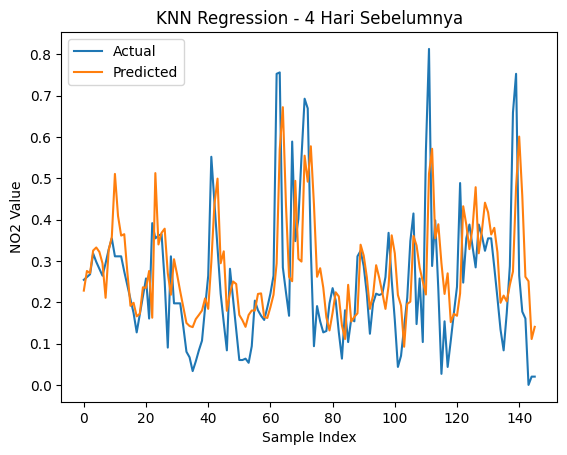

In [62]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(np.arange(len(y_test_4)), y_test_4, label="Actual")
plt.plot(np.arange(len(y_pred_4)), y_pred_4, label="Predicted")
plt.title("KNN Regression - 4 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

Grafik ini menampilkan perbandingan antara nilai aktual dan hasil prediksi menggunakan model KNN dengan 4 hari sebelumnya sebagai input. Garis prediksi terlihat mampu mengikuti pola umum data aktual meskipun masih terdapat beberapa perbedaan pada titik-titik tertentu.

Secara umum, model telah mampu menangkap tren data dengan cukup baik, sehingga dapat digunakan untuk proses peramalan pada periode berikutnya.


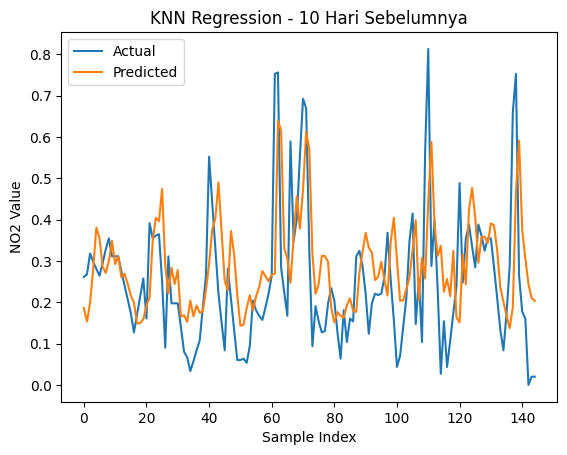

In [63]:
plt.figure()
plt.plot(np.arange(len(y_test_10)), y_test_10, label="Actual")
plt.plot(np.arange(len(y_pred_10)), y_pred_10, label="Predicted")
plt.title("KNN Regression - 10 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

 Hasil prediksi mampu mengikuti pola perubahan data, namun masih terdapat beberapa selisih pada nilai puncak dan lembah.

Secara keseluruhan, model dapat menggambarkan tren data dengan cukup baik, meskipun akurasinya masih perlu ditingkatkan untuk memperoleh hasil prediksi yang lebih mendekati nilai aktual.


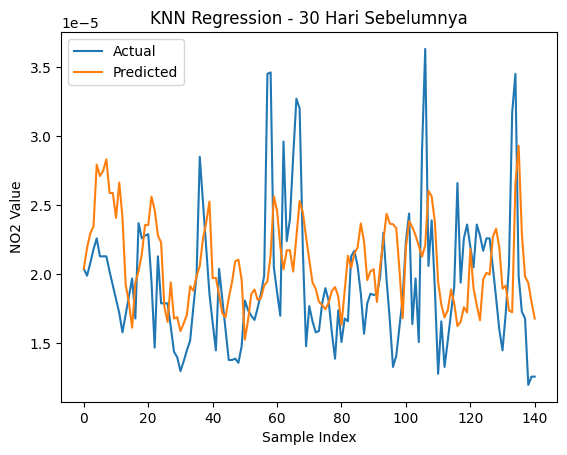

In [64]:
plt.figure()
plt.plot(np.arange(len(y_test_30)), y_test_30, label="Actual")
plt.plot(np.arange(len(y_pred_30)), y_pred_30, label="Predicted")
plt.title("KNN Regression - 30 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

Hasil prediksi masih dapat mengikuti pola umum data, namun terlihat lebih sulit menangkap perubahan nilai yang terjadi secara tajam.

Secara keseluruhan, model mampu menggambarkan tren data, tetapi performanya cenderung lebih rendah dibandingkan penggunaan data historis yang lebih pendek.
